In [6]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats
from endgame import hist2d

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [5]:
cd ..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# VPD helper functions
# ------------------------------------------------------------

def calc_vpd_from_t_q(t, q, p_hpa=1000.):
    """
    Calculate vapour pressure deficit from temperature and specific humidity.

    t     : temperature, usually K. If values look like Celsius, code handles it.
    q     : specific humidity, usually kg/kg. If values look like g/kg, code converts.
    p_hpa : pressure in hPa. Use 1000 hPa as near-surface approximation unless you have psfc.

    returns VPD in hPa.
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    # If q looks like g/kg, convert to kg/kg
    q = np.where(q > 0.1, q / 1000., q)

    # If T looks like Celsius, convert to Kelvin
    t_k = np.where(t < 150, t + 273.15, t)
    t_c = t_k - 273.15

    # saturation vapour pressure, hPa
    es = 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))

    # actual vapour pressure from specific humidity, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1 - eps) * q)

    vpd = es - e
    return vpd


def add_vpd_to_abs_and_anom(abs_df, anom_df, suffix='1deg', p_hpa=1000.):
    """
    Adds VPD to both:
    - abs_df: storm-day absolute VPD
    - anom_df: storm-day VPD anomaly relative to that period's own climate

    Uses:
    storm climate T = storm absolute T - storm T anomaly
    storm climate q = storm absolute q - storm q anomaly
    """

    tvar = f't_srfc_{suffix}'
    qvar = f'q_srfc_{suffix}'
    outvar = f'vpd_srfc_{suffix}'

    # storm-day absolute VPD
    vpd_abs = calc_vpd_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)

    # reconstruct that period's local/day climatology for T and q
    t_clim = abs_df[tvar] - anom_df[tvar]
    q_clim = abs_df[qvar] - anom_df[qvar]

    # climatological VPD
    vpd_clim = calc_vpd_from_t_q(t_clim, q_clim, p_hpa=p_hpa)

    # add to dataframes
    abs_df[outvar] = vpd_abs
    anom_df[outvar] = vpd_abs - vpd_clim

    return abs_df, anom_df

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def calc_ef(lh, sh):
    """
    Evaporative fraction:
        EF = LH / (LH + SH)

    Assumes LH and SH are in the same units, e.g. W m-2.
    """
    lh = np.asarray(lh, dtype=float)
    sh = np.asarray(sh, dtype=float)

    denom = lh + sh
    ef = np.where(np.isclose(denom, 0) | np.isnan(denom), np.nan, lh / denom)
    return ef


def add_ef_to_abs_and_anom(abs_df, anom_df, suffix='1deg'):
    """
    Adds:
    - ef_1deg to abs_df  = EF from storm-day absolute LH/SH
    - ef_1deg to anom_df = EF_abs - EF_clim

    Do this separately for hist and fut.
    """

    lhvar = f'lh_{suffix}'
    shvar = f'sh_{suffix}'
    outvar = f'ef_{suffix}'

    # storm-day absolute EF
    ef_abs = calc_ef(abs_df[lhvar], abs_df[shvar])

    # reconstruct each period's climatological LH/SH
    lh_clim = abs_df[lhvar] - anom_df[lhvar]
    sh_clim = abs_df[shvar] - anom_df[shvar]

    # climatological EF
    ef_clim = calc_ef(lh_clim, sh_clim)

    # add derived absolute and derived anomaly
    abs_df[outvar] = ef_abs*100
    anom_df[outvar] = (ef_abs - ef_clim)*100

    return abs_df, anom_df

In [9]:
import numpy as np

def calc_thetae_from_t_q(t, q, p_hpa=925.):
    """
    Calculate equivalent potential temperature from temperature and specific humidity.

    t     : temperature, K or degC
    q     : specific humidity, kg/kg or g/kg
    p_hpa : pressure in hPa

    returns theta-e in K
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    # q: g/kg -> kg/kg if needed
    q = np.where(q > 0.1, q / 1000., q)

    # T: Celsius -> Kelvin if needed
    t_k = np.where(t < 150, t + 273.15, t)

    # avoid impossible q values
    q = np.where((q <= 0) | (q >= 1), np.nan, q)

    # mixing ratio, kg/kg
    r = q / (1. - q)

    # vapour pressure, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1. - eps) * q)
    e = np.where(e <= 0, np.nan, e)

    # dewpoint from vapour pressure, K
    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    # LCL temperature, K; Bolton-style approximation
    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    # potential temperature
    rd_cp = 0.2854
    theta = t_k * (1000. / p_hpa) ** rd_cp

    # equivalent potential temperature
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    return thetae

In [ ]:
def add_thetae_to_abs_and_anom(abs_df, anom_df, suffix='1deg', p_hpa=925.):
    """
    Adds theta-e to storm-day absolute and anomaly dataframes.

    abs_df  : lhist or lfut
    anom_df : lahist or lafut

    Adds:
        thetae_calc_1deg to abs_df
        thetae_calc_1deg to anom_df

    thetae anomaly is calculated as:
        thetae_abs - thetae_clim
    """

    tvar = f't_srfc_{suffix}'
    qvar = f'q_srfc_{suffix}'
    outvar = f'thetae_{suffix}'

    thetae_abs = calc_thetae_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)

    t_clim = abs_df[tvar] - anom_df[tvar]
    q_clim = abs_df[qvar] - anom_df[qvar]

    thetae_clim = calc_thetae_from_t_q(t_clim, q_clim, p_hpa=p_hpa)

    abs_df[outvar] = thetae_abs
    anom_df[outvar] = thetae_abs - thetae_clim

    return abs_df, anom_df

In [11]:
import numpy as np

def saturation_vapour_pressure_hpa(t_k):
    """
    Saturation vapour pressure over liquid water, hPa.
    Input T in K.
    """
    t_c = t_k - 273.15
    return 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))


def calc_thetae_from_t_q(t, q, p_hpa=925.):
    """
    Equivalent potential temperature from T and specific humidity.

    t     : K or degC
    q     : kg/kg or g/kg
    p_hpa : hPa

    returns theta-e in K
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    q = np.where(q > 0.1, q / 1000., q)       # g/kg -> kg/kg if needed
    t_k = np.where(t < 150, t + 273.15, t)   # degC -> K if needed

    q = np.where((q <= 0) | (q >= 1), np.nan, q)

    r = q / (1. - q)

    eps = 0.622
    e = (q * p_hpa) / (eps + (1. - eps) * q)
    e = np.where(e <= 0, np.nan, e)

    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    theta = t_k * (1000. / p_hpa) ** 0.2854
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    return thetae


def calc_thetaes_from_t(t, p_hpa=650.):
    """
    Saturated equivalent potential temperature from T and pressure.

    t     : K or degC
    p_hpa : hPa

    returns saturated theta-e in K
    """

    t = np.asarray(t, dtype=float)
    t_k = np.where(t < 150, t + 273.15, t)

    eps = 0.622

    es = saturation_vapour_pressure_hpa(t_k)
    es = np.where(es >= 0.99 * p_hpa, np.nan, es)

    rs = eps * es / (p_hpa - es)

    # saturated parcel: dewpoint = temperature, LCL approximately T
    tlcl = t_k

    theta = t_k * (1000. / p_hpa) ** 0.2854
    thetaes = theta * np.exp((3376. / tlcl - 2.54) * rs * (1. + 0.81 * rs))

    return thetaes

In [12]:
def add_cape_proxy_to_abs_and_anom(abs_df, anom_df, suffix='1deg',
                                   p_srfc_hpa=925., p_mid_hpa=650.):
    """
    Adds table-based two-level CAPE proxy:

        cape_proxy_calc = thetae_srfc - thetaes_mid

    to both absolute and anomaly dataframes.

    The anomaly is calculated as:

        cape_proxy_abs - cape_proxy_clim

    not from anomaly T/q directly.
    """

    t_s_var = f't_srfc_{suffix}'
    q_s_var = f'q_srfc_{suffix}'
    t_m_var = f't_mid_{suffix}'

    thetae_var  = f'thetae_calc_{suffix}'
    thetaes_var = f'thetaes_mid_calc_{suffix}'
    cape_var    = f'cape_proxy_calc_{suffix}'

    # storm-day absolute values
    thetae_s_abs = calc_thetae_from_t_q(abs_df[t_s_var], abs_df[q_s_var],
                                        p_hpa=p_srfc_hpa)

    thetaes_m_abs = calc_thetaes_from_t(abs_df[t_m_var],
                                        p_hpa=p_mid_hpa)

    cape_abs = thetae_s_abs - thetaes_m_abs

    # reconstruct period climatology
    t_s_clim = abs_df[t_s_var] - anom_df[t_s_var]
    q_s_clim = abs_df[q_s_var] - anom_df[q_s_var]
    t_m_clim = abs_df[t_m_var] - anom_df[t_m_var]

    thetae_s_clim = calc_thetae_from_t_q(t_s_clim, q_s_clim,
                                         p_hpa=p_srfc_hpa)

    thetaes_m_clim = calc_thetaes_from_t(t_m_clim,
                                         p_hpa=p_mid_hpa)

    cape_clim = thetae_s_clim - thetaes_m_clim

    # add to dataframes
    abs_df[thetae_var] = thetae_s_abs
    abs_df[thetaes_var] = thetaes_m_abs
    abs_df[cape_var] = cape_abs

    anom_df[thetae_var] = thetae_s_abs - thetae_s_clim
    anom_df[thetaes_var] = thetaes_m_abs - thetaes_m_clim
    anom_df[cape_var] = cape_abs - cape_clim

    return abs_df, anom_df

In [13]:
lhist_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_mean_table_JASMIN_3hmeansVersion_rainMask.csv', index_col=0, low_memory=False).T
lfut_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_mean_table_JASMIN_3hmeansVersion_rainMask.csv', index_col=0, low_memory=False).T

In [14]:
lahist_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_anom_table_JASMIN_3hmeansVersion_rainMask.csv', index_col=0, low_memory=False).T
lafut_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_anom_table_JASMIN_3hmeansVersion_rainMask.csv', index_col=0, low_memory=False).T

In [15]:
for dat in [lahist_orig, lafut_orig, lhist_orig, lfut_orig]:
    for var in dat.keys():
        try:
            dat[var] = dat[var].astype(float)
        except:
            pass

In [16]:
keys = ["pmax", "area", "area_1mm"]
 
common = pd.merge(lahist_orig[keys].drop_duplicates(),lhist_orig[keys].drop_duplicates(),on=keys,how="inner")
lahist_orig = lahist_orig.merge(common, on=keys, how="inner")
lhist_orig = lhist_orig.merge(common, on=keys, how="inner")
 
common = pd.merge(lafut_orig[keys].drop_duplicates(),lfut_orig[keys].drop_duplicates(),on=keys,how="inner")
lafut_orig = lafut_orig.merge(common, on=keys, how="inner")
lfut_orig = lfut_orig.merge(common, on=keys, how="inner")

In [17]:
lahist, lafut, lhist, lfut= [df.copy() for df in (lahist_orig, lafut_orig, lhist_orig, lfut_orig)]

In [18]:
len(lahist)

20014

In [19]:
len(lhist)

20014

In [20]:
np.unique(lahist['month'])

array([7., 8., 9.])

In [21]:
np.unique(lhist['hour'])

array([17., 18., 19.])

In [22]:
lahist['area_1mm'].min()*4.4**2

19.360000000000003

In [23]:
lahist['pmax'].min()

0.4134321472886568

In [24]:
lahist['shear_1deg'].max()

16.298389434814453

In [25]:
print(list(lafut.keys()))
dtag = '2deg'

['tcwv_0.25deg', 'tcwv_1deg', 'tcwv_2deg', 'sh_0.25deg', 'sh_1deg', 'sh_2deg', 'lh_0.25deg', 'lh_1deg', 'lh_2deg', 't2_0.25deg', 't2_1deg', 't2_2deg', 'q2_0.25deg', 'q2_1deg', 'q2_2deg', 'shear_0.25deg', 'shear_1deg', 'shear_2deg', 'u_mid_0.25deg', 'u_mid_1deg', 'u_mid_2deg', 'u_srfc_0.25deg', 'u_srfc_1deg', 'u_srfc_2deg', 'v_mid_0.25deg', 'v_mid_1deg', 'v_mid_2deg', 'v_srfc_0.25deg', 'v_srfc_1deg', 'v_srfc_2deg', 'q_mid_0.25deg', 'q_mid_1deg', 'q_mid_2deg', 't_mid_0.25deg', 't_mid_1deg', 't_mid_2deg', 't_srfc_0.25deg', 't_srfc_1deg', 't_srfc_2deg', 'q_srfc_0.25deg', 'q_srfc_1deg', 'q_srfc_2deg', 'geoH_srfc_0.25deg', 'geoH_srfc_1deg', 'geoH_srfc_2deg', 'lsRain_noon_0.25deg', 'lsRain_noon_1deg', 'lsRain_noon_2deg', 'lwout_noon_0.25deg', 'lwout_noon_1deg', 'lwout_noon_2deg', 'SM_0.25deg', 'SM_1deg', 'SM_2deg', 'lw_net_0.25deg', 'lw_net_1deg', 'lw_net_2deg', 'sw_in_0.25deg', 'sw_in_1deg', 'sw_in_2deg', 'sw_net_0.25deg', 'sw_net_1deg', 'sw_net_2deg', 'u10_0.25deg', 'u10_1deg', 'u10_2deg', 

In [26]:
lhist, lahist = add_vpd_to_abs_and_anom(lhist, lahist, suffix=dtag, p_hpa=925.)
lfut,  lafut  = add_vpd_to_abs_and_anom(lfut,  lafut,  suffix=dtag, p_hpa=925.)

In [27]:
lhist, lahist = add_ef_to_abs_and_anom(lhist, lahist, suffix=dtag)
lfut,  lafut  = add_ef_to_abs_and_anom(lfut,  lafut,  suffix=dtag)

In [28]:
lhist, lahist = add_thetae_to_abs_and_anom(lhist, lahist, suffix=dtag, p_hpa=925.)
lfut,  lafut  = add_thetae_to_abs_and_anom(lfut,  lafut,  suffix=dtag, p_hpa=925.)

In [29]:
lhist, lahist = add_cape_proxy_to_abs_and_anom(lhist, lahist, suffix=dtag, p_srfc_hpa=925., p_mid_hpa=650.)

lfut, lafut = add_cape_proxy_to_abs_and_anom(lfut, lafut, suffix=dtag, p_srfc_hpa=925., p_mid_hpa=650.)

-3.058959740465852 1.2856546758422722 -4.4659512074803445 0.16075180914582785
ef_2deg 71.94823604185927 53.5960995961579 69.01336302174158 43.25827918645031
t2_2deg 301.41526378532296 303.5311952994649 306.78359013386773 309.35728850938466
div_2deg 0.4208736165862165 0.23956545824756567 0.14193552491638847 -0.3808837564020808
v_mid_2deg -0.4347101208855451 -2.156974258643067 -0.8479456247450661 -2.3933850790211912
tcwv_2deg 45.816421127819126 44.54147625857839 66.94220380161183 65.87912986996342


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

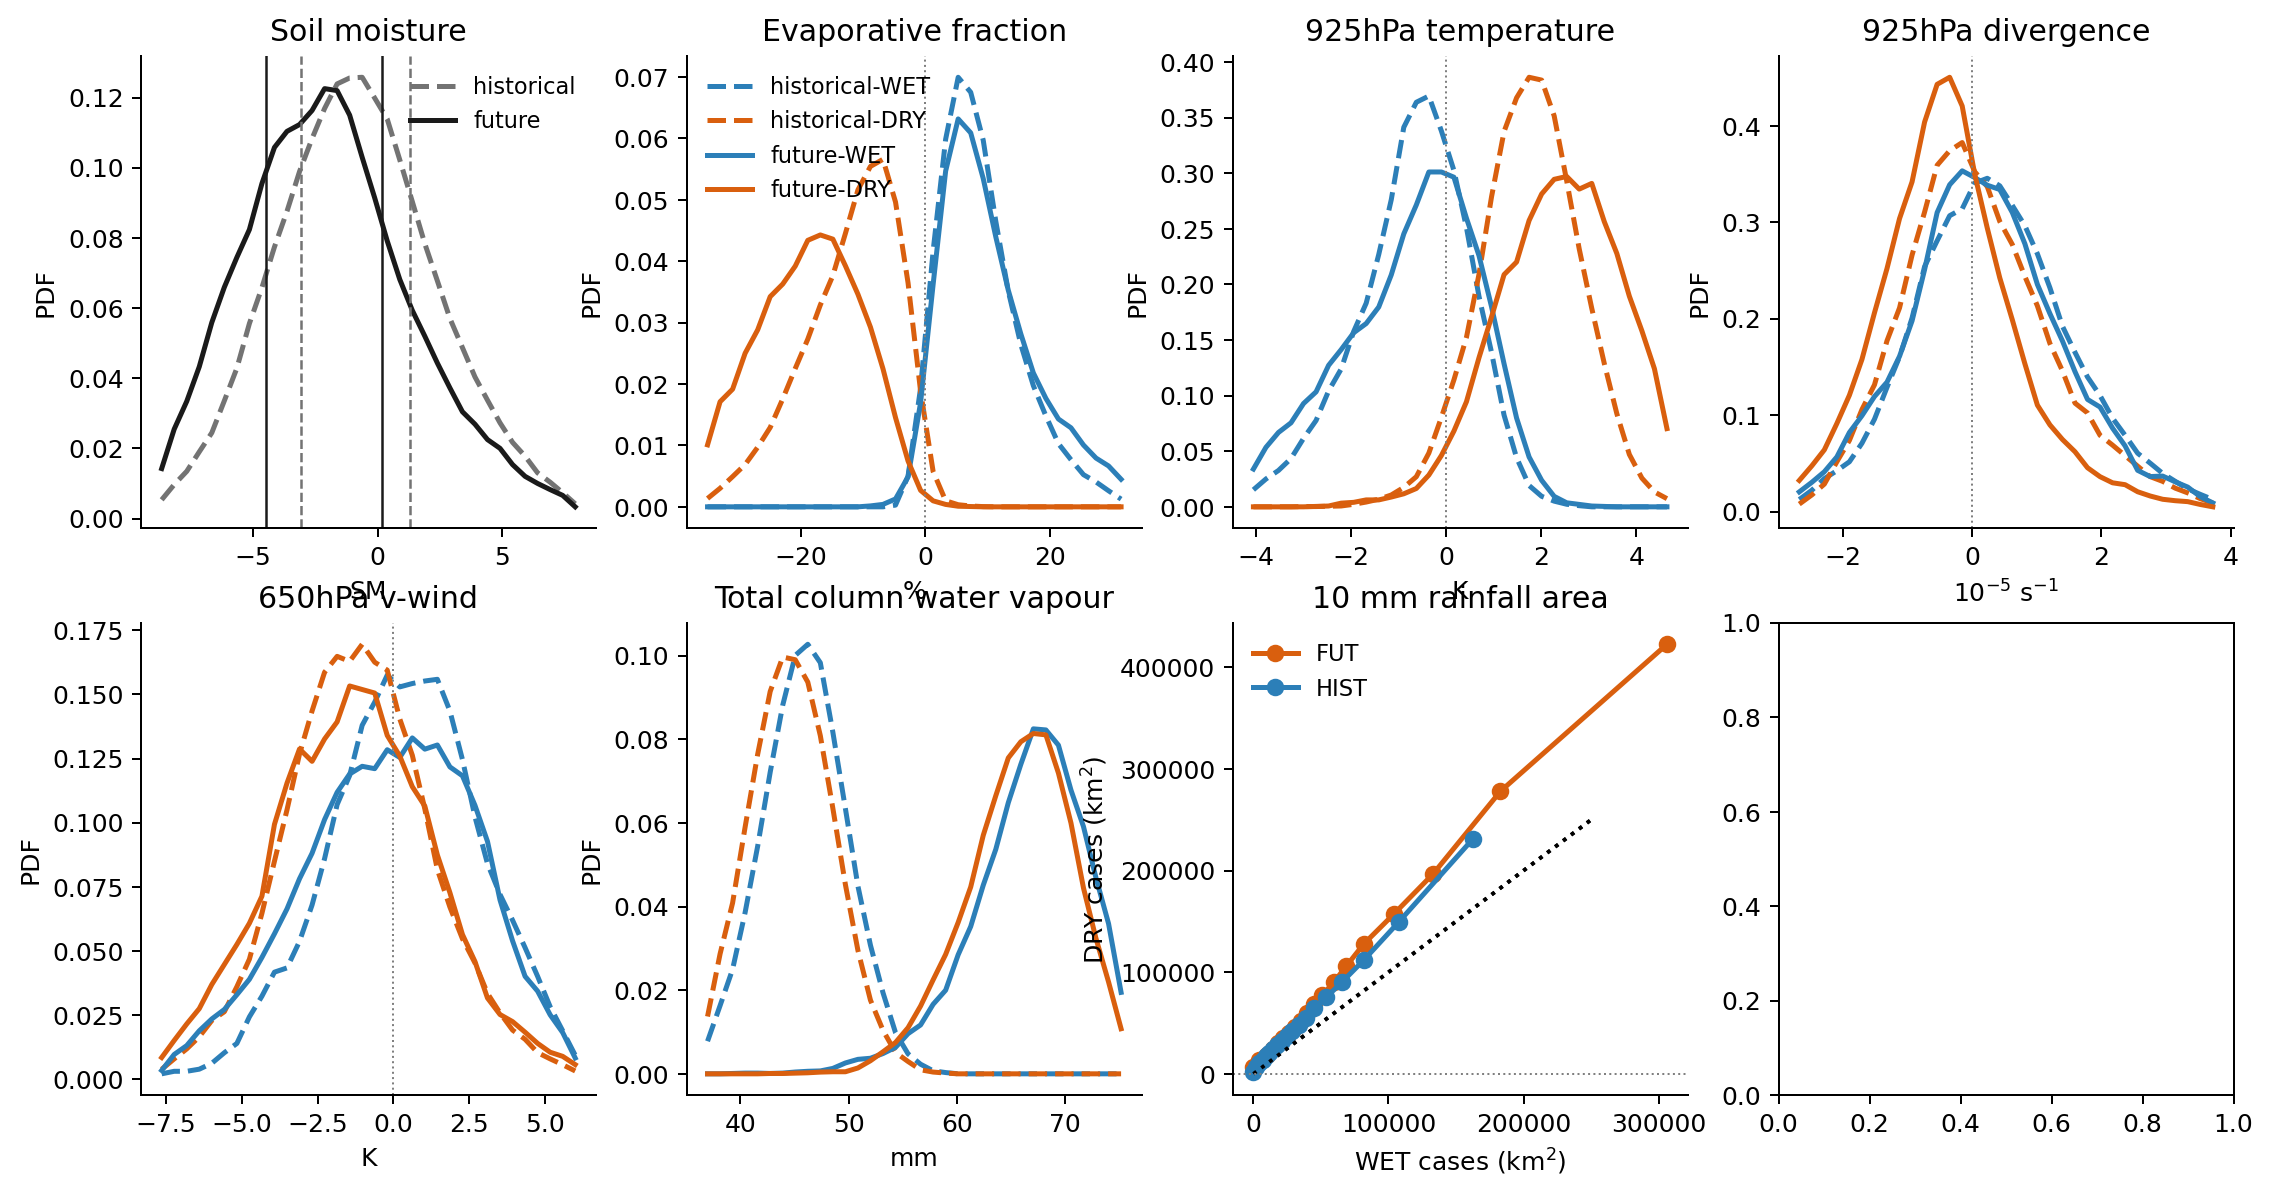

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SM split (same logic as your current code)
# ------------------------------------------------------------
histp25, histp75 = np.nanpercentile(lahist['SM_2deg'], [25, 75])
futp25, futp75   = np.nanpercentile(lafut['SM_2deg'], [25, 75])

histposlow  = lahist['SM_'+dtag] > histp75   # WET
histposhigh = lahist['SM_'+dtag] < histp25   # DRY
futposlow   = lafut['SM_'+dtag] > futp75     # WET
futposhigh  = lafut['SM_'+dtag] < futp25     # DRY

print(histp25, histp75, futp25, futp75)


# ------------------------------------------------------------
# Colours / styles
# ------------------------------------------------------------
wet_col  = '#2C7FB8'
dry_col  = '#D95F0E'
hist_col = '0.45'
fut_col  = '0.10'


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean(x, scale=1):
    x = np.asarray(x, dtype=float) * scale
    return x[np.isfinite(x)]

def _smooth(y, n=3):
    if n <= 1:
        return y
    kernel = np.ones(n) / n
    return np.convolve(y, kernel, mode='same')

def _make_bins(arrs, nbins=36, qrange=(1, 99)):
    zz = np.concatenate([a for a in arrs if len(a) > 0])
    lo, hi = np.nanpercentile(zz, qrange)
    return np.linspace(lo, hi, nbins + 1)

def _pdf(vals, bins, smooth=3):
    h, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5 * (edges[1:] + edges[:-1])
    return mids, _smooth(h, n=smooth)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

def plot_sm_pdf(ax):
    hsm = _clean(lahist['SM_2deg'])
    fsm = _clean(lafut['SM_2deg'])
    bins = _make_bins([hsm, fsm], nbins=34, qrange=(1, 99))

    x, y = _pdf(hsm, bins, smooth=3)
    ax.plot(x, y, color=hist_col, ls='--', lw=2, label='historical')

    x, y = _pdf(fsm, bins, smooth=3)
    ax.plot(x, y, color=fut_col, ls='-', lw=2, label='future')

    ax.axvline(histp25, color=hist_col, ls='--', lw=1)
    ax.axvline(histp75, color=hist_col, ls='--', lw=1)
    ax.axvline(futp25,  color=fut_col,  ls='-',  lw=1)
    ax.axvline(futp75,  color=fut_col,  ls='-',  lw=1)

    ymax = ax.get_ylim()[1]
    # ax.text(histp25, ymax*0.95, 'H25', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(histp75, ymax*0.95, 'H75', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(futp25,  ymax*0.85, 'F25', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)
    # ax.text(futp75,  ymax*0.85, 'F75', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)

    ax.set_title('Soil moisture')
    ax.set_xlabel('SM')
    ax.set_ylabel('PDF')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_group_pdf(ax, var, title, xlabel, scale=1, zero_line=False, nbins=34, qrange=(1, 99), smooth=3):

    if 'tcwv' not in var:
        hwet = _clean(lahist[var][histposlow], scale=scale)
        hdry = _clean(lahist[var][histposhigh], scale=scale)
        fwet = _clean(lafut[var][futposlow], scale=scale)
        fdry = _clean(lafut[var][futposhigh], scale=scale)
    else:
        hwet = _clean(lhist[var][histposlow], scale=scale)
        hdry = _clean(lhist[var][histposhigh], scale=scale)
        fwet = _clean(lfut[var][futposlow], scale=scale)
        fdry = _clean(lfut[var][futposhigh], scale=scale)

    hwet_mean = _clean(lhist[var][histposlow], scale=scale)
    hdry_mean = _clean(lhist[var][histposhigh], scale=scale)
    fwet_mean = _clean(lfut[var][futposlow], scale=scale)
    fdry_mean = _clean(lfut[var][futposhigh], scale=scale)

    print(var, np.mean(hwet_mean), np.mean(hdry_mean), np.mean(fwet_mean), np.mean(fdry_mean))

    bins = _make_bins([hwet, hdry, fwet, fdry], nbins=nbins, qrange=qrange)

    for vals, col, ls, lab in [
        (hwet, wet_col, '--', 'historical-WET'),
        (hdry, dry_col, '--', 'historical-DRY'),
        (fwet, wet_col, '-',  'future-WET'),
        (fdry, dry_col, '-',  'future-DRY')
    ]:
        x, y = _pdf(vals, bins, smooth=smooth)
        ax.plot(x, y, color=col, ls=ls, lw=2, label=lab)

    if zero_line:
        ax.axvline(0, color='0.5', ls=':', lw=0.8)
        
    if 'ef' in var:
        ax.legend(frameon=False, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    style_ax(ax)

def plot_area_panel(ax):
    # convert to km² if your area_10mm is in pixels
    pp = np.arange(5, 99, 5)

    # groups = [
    #     ('WET', _clean(lhist['area_1mm'][histposlow]),  _clean(lfut['area_1mm'][futposlow]),  wet_col),
    #    # ('ALL', _clean(lahist['area_10mm']),              _clean(lafut['area_10mm']),              '0.10'),
    #     ('DRY', _clean(lhist['area_1mm'][histposhigh]), _clean(lfut['area_1mm'][futposhigh]), dry_col)
    # ]
    groups = [
        ('FUT', _clean(lfut['area_5mm'][futposlow]),  _clean(lfut['area_5mm'][futposhigh]),  dry_col),
     #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
        ('HIST', _clean(lhist['area_5mm'][histposlow]), _clean(lhist['area_5mm'][histposhigh]), wet_col)
    ]

    for lab, histv, futv, col in groups:
        hq = np.nanpercentile((histv)*4.4**2, pp)
        fq = np.nanpercentile((futv)*4.4**2, pp)
        #ax.plot((hq)*4.4**2, (fq - hq)*4.4**2, color=col, lw=2, label=lab, marker='o')
        
        ax.plot((hq)*4.4**2, (fq)*4.4**2, color=col, lw=2, label=lab, marker='o')
        ax.plot(np.linspace(0,250000,10), np.linspace(0,250000,10), color='k', linestyle='dotted')
        
    ax.axhline(0, color='0.5', ls=':', lw=0.8)

    ax.set_title('10 mm rainfall area')
    ax.set_xlabel(r'WET cases (km$^{2}$)')
    ax.set_ylabel('DRY cases (km$^{2}$)')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_pmax_panel(ax):
    pp = np.arange(5, 99, 5)

    # groups = [
    #     ('WET', _clean(lhist['pmax'][histposlow]),  _clean(lfut['pmax'][futposlow]),  wet_col),
    #  #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
    #     ('DRY', _clean(lhist['pmax'][histposhigh]), _clean(lfut['pmax'][futposhigh]), dry_col)
    # ]

    groups = [
        ('FUT', _clean(lfut['pmax'][futposlow]),  _clean(lfut['pmax'][futposhigh]),  dry_col),
     #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
        ('HIST', _clean(lhist['pmax'][histposlow]), _clean(lhist['pmax'][histposhigh]), wet_col)
    ]


    for lab, histv, futv, col in groups:
        hq = np.nanpercentile(histv, pp)
        fq = np.nanpercentile(futv, pp)
        #ax.plot(hq, (fq - hq), color=col, lw=2, label=lab, marker='o')
        ax.plot(hq, fq, color=col, lw=2, label=lab, marker='o')
        ax.plot(np.linspace(0,81,10), np.linspace(0,81,10), color='k', linestyle='dotted')

    ax.axhline(0, color='0.5', ls=':', lw=0.8)
    ax.set_title('Maximum rainfall')
    ax.set_xlabel(r'WET cases (mm h$^{-1}$)')
    ax.set_ylabel('DRY cases (mm h$^{-1}$)')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(2,4, figsize=(15, 7.5), dpi=180)
axs = axs.ravel()

# 1) full SM distribution
plot_sm_pdf(axs[0])

# 2-6) associated environmental variables
plot_group_pdf(axs[1], 'ef_'+dtag,   'Evaporative fraction',         '%', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[2], 't2_'+dtag,   '925hPa temperature',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[3], 'div_'+dtag,  '925hPa divergence',     '$10^{-5}$ s$^{-1}$', scale=1e5, zero_line=True, nbins=34, qrange=(1, 99)),
plot_group_pdf(axs[4], 'v_mid_'+dtag,   r'650hPa v-wind',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[5], 'tcwv_'+dtag,   'Total column water vapour','mm',         zero_line=False, nbins=34, qrange=(1, 99))

               

# 7-8) storm characteristics
plot_area_panel(axs[6])
plot_pmax_panel(axs[7])

plt.tight_layout()
# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SMsplit_variable_distributions_clean.png', dpi=200)
plt.show()

In [474]:
lahist = lahist.loc[(lahist["hour"].isin([17,18,19])) & (lhist["pmax"] > 1) &  (lhist['v_mid_'+dtag] < -1)].copy()
lhist = lhist.loc[(lhist["hour"].isin([17,18,19])) & (lhist["pmax"] > 1) &  (lhist['v_mid_'+dtag] < -1) ].copy()
lafut = lafut.loc[(lafut["hour"].isin([17,18,19])) & (lfut["pmax"] > 1) &  (lfut['v_mid_'+dtag] < -1)].copy()
lfut = lfut.loc[(lfut["hour"].isin([17,18,19])) & (lfut["pmax"] > 1) &  (lfut['v_mid_'+dtag] < -1)].copy()

In [475]:
len(lahist)

10830

-3.6630570881171143 0.5909173327980156 -5.078310156647522 -0.4308343016939712
ef_2deg 72.98912983782698 54.09063270636477 70.73456134251153 43.73554095536705
2708 2708 1955 1955
t2_2deg 301.20712568180824 303.5569479442019 306.5351529353776 309.3675234749519
2708 2708 1955 1955
div_2deg 0.30807751360769287 0.12698273901454135 -0.042804755836692285 -0.5791494033908944
2541 2631 1821 1927
v_mid_2deg -3.003226775230298 -3.4527486905653686 -3.543864119571188 -3.979182083466474
2708 2708 1955 1955
tcwv_2deg 45.369075635542245 44.30170689173949 67.22270329084385 65.54189742632681
2708 2708 1955 1955


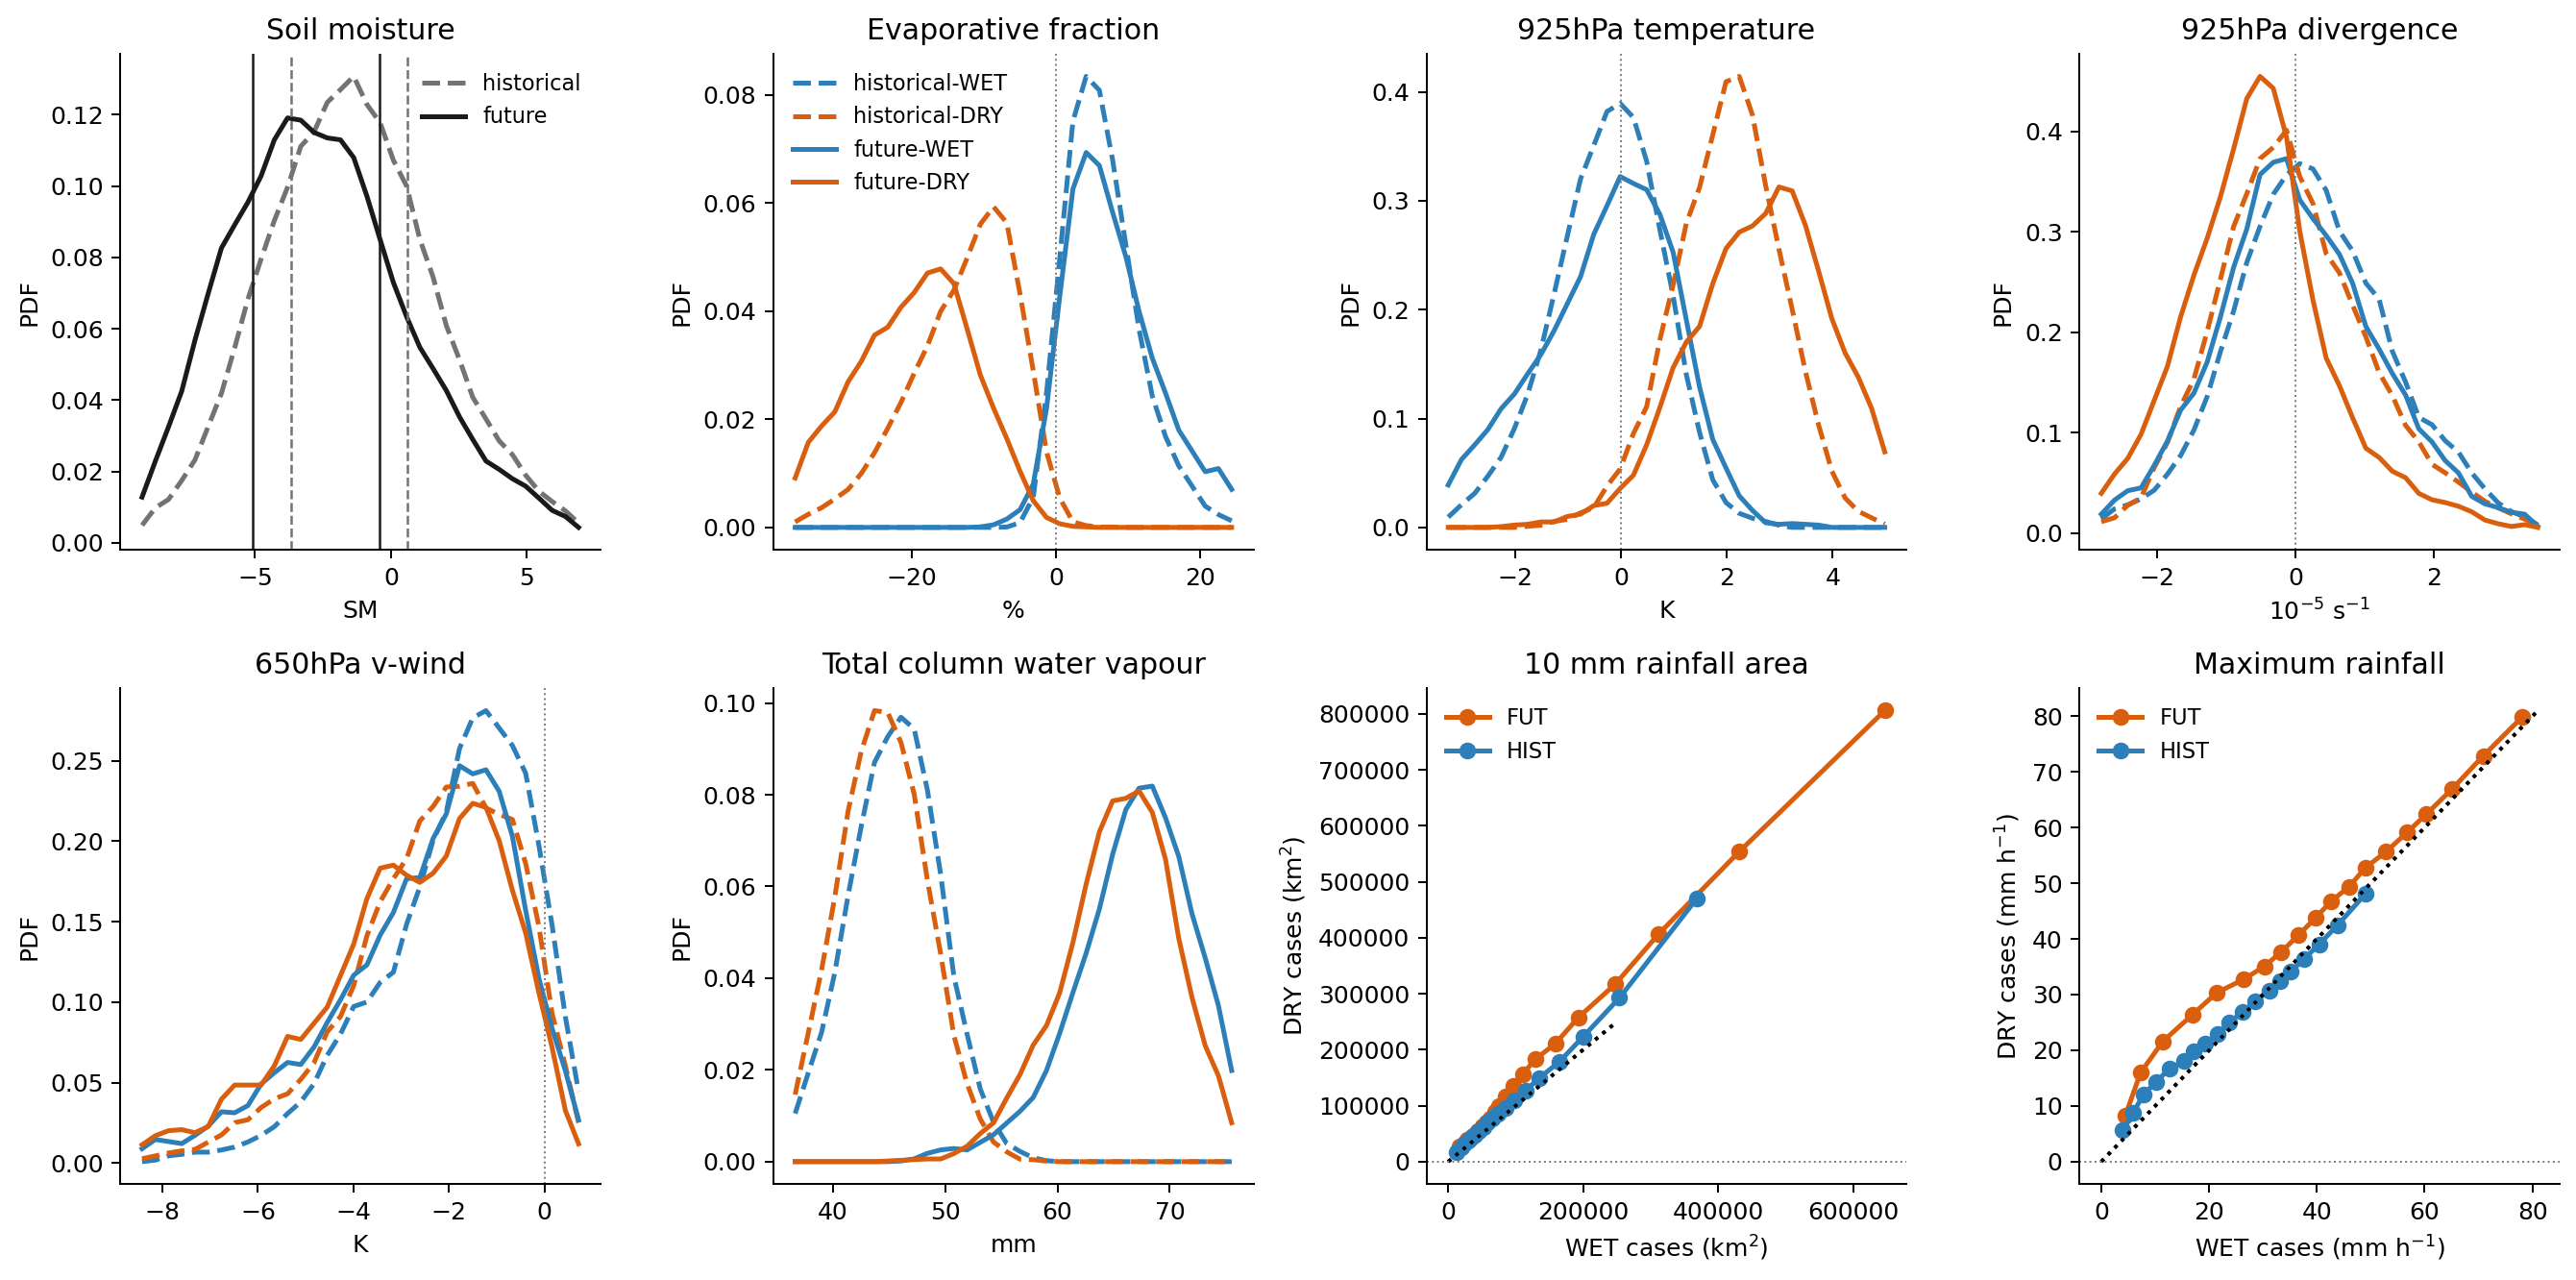

In [476]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SM split (same logic as your current code)
# ------------------------------------------------------------
histp25, histp75 = np.nanpercentile(lahist['SM_'+dtag], [25, 75])
futp25, futp75   = np.nanpercentile(lafut['SM_'+dtag], [25, 75])

histposlow  = lahist['SM_'+dtag] > histp75   # WET
histposhigh = lahist['SM_'+dtag] < histp25   # DRY
futposlow   = lafut['SM_'+dtag] > futp75     # WET
futposhigh  = lafut['SM_'+dtag] < futp25     # DRY

print(histp25, histp75, futp25, futp75)


# ------------------------------------------------------------
# Colours / styles
# ------------------------------------------------------------
wet_col  = '#2C7FB8'
dry_col  = '#D95F0E'
hist_col = '0.45'
fut_col  = '0.10'


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean(x, scale=1):
    x = np.asarray(x, dtype=float) * scale
    return x[np.isfinite(x)]

def _smooth(y, n=3):
    if n <= 1:
        return y
    kernel = np.ones(n) / n
    return np.convolve(y, kernel, mode='same')

def _make_bins(arrs, nbins=36, qrange=(1, 99)):
    zz = np.concatenate([a for a in arrs if len(a) > 0])
    lo, hi = np.nanpercentile(zz, qrange)
    return np.linspace(lo, hi, nbins + 1)

def _pdf(vals, bins, smooth=3):
    h, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5 * (edges[1:] + edges[:-1])
    return mids, _smooth(h, n=smooth)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

def plot_sm_pdf(ax):
    hsm = _clean(lahist['SM_2deg'])
    fsm = _clean(lafut['SM_2deg'])
    bins = _make_bins([hsm, fsm], nbins=34, qrange=(1, 99))

    x, y = _pdf(hsm, bins, smooth=3)
    ax.plot(x, y, color=hist_col, ls='--', lw=2, label='historical')

    x, y = _pdf(fsm, bins, smooth=3)
    ax.plot(x, y, color=fut_col, ls='-', lw=2, label='future')

    ax.axvline(histp25, color=hist_col, ls='--', lw=1)
    ax.axvline(histp75, color=hist_col, ls='--', lw=1)
    ax.axvline(futp25,  color=fut_col,  ls='-',  lw=1)
    ax.axvline(futp75,  color=fut_col,  ls='-',  lw=1)

    ymax = ax.get_ylim()[1]
    # ax.text(histp25, ymax*0.95, 'H25', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(histp75, ymax*0.95, 'H75', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(futp25,  ymax*0.85, 'F25', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)
    # ax.text(futp75,  ymax*0.85, 'F75', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)

    ax.set_title('Soil moisture')
    ax.set_xlabel('SM')
    ax.set_ylabel('PDF')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_group_pdf(ax, var, title, xlabel, scale=1, zero_line=False, nbins=34, qrange=(1, 99), smooth=3):

    if 'tcwv' not in var:
        hwet = _clean(lahist[var][histposlow], scale=scale)
        hdry = _clean(lahist[var][histposhigh], scale=scale)
        fwet = _clean(lafut[var][futposlow], scale=scale)
        fdry = _clean(lafut[var][futposhigh], scale=scale)
    else:
        hwet = _clean(lhist[var][histposlow], scale=scale)
        hdry = _clean(lhist[var][histposhigh], scale=scale)
        fwet = _clean(lfut[var][futposlow], scale=scale)
        fdry = _clean(lfut[var][futposhigh], scale=scale)

    hwet_mean = _clean(lhist[var][histposlow], scale=scale)
    hdry_mean = _clean(lhist[var][histposhigh], scale=scale)
    fwet_mean = _clean(lfut[var][futposlow], scale=scale)
    fdry_mean = _clean(lfut[var][futposhigh], scale=scale)

    print(var, np.mean(hwet_mean), np.mean(hdry_mean), np.mean(fwet_mean), np.mean(fdry_mean))
    print(len(hwet_mean), len(hdry_mean), len(fwet_mean), len(fdry_mean))

    bins = _make_bins([hwet, hdry, fwet, fdry], nbins=nbins, qrange=qrange)

    for vals, col, ls, lab in [
        (hwet, wet_col, '--', 'historical-WET'),
        (hdry, dry_col, '--', 'historical-DRY'),
        (fwet, wet_col, '-',  'future-WET'),
        (fdry, dry_col, '-',  'future-DRY')
    ]:
        x, y = _pdf(vals, bins, smooth=smooth)
        ax.plot(x, y, color=col, ls=ls, lw=2, label=lab)

    if zero_line:
        ax.axvline(0, color='0.5', ls=':', lw=0.8)
        
    if 'ef' in var:
        ax.legend(frameon=False, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    style_ax(ax)

def plot_area_panel(ax):
    # convert to km² if your area_10mm is in pixels
    pp = np.arange(5, 99, 5)

    # groups = [
    #     ('WET', _clean(lhist['area_1mm'][histposlow]),  _clean(lfut['area_1mm'][futposlow]),  wet_col),
    #    # ('ALL', _clean(lahist['area_10mm']),              _clean(lafut['area_10mm']),              '0.10'),
    #     ('DRY', _clean(lhist['area_1mm'][histposhigh]), _clean(lfut['area_1mm'][futposhigh]), dry_col)
    # ]
    groups = [
        ('FUT', _clean(lfut['area_1mm'][futposlow]),  _clean(lfut['area_1mm'][futposhigh]),  dry_col),
     #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
        ('HIST', _clean(lhist['area_1mm'][histposlow]), _clean(lhist['area_1mm'][histposhigh]), wet_col)
    ]

    for lab, histv, futv, col in groups:
        hq = np.nanpercentile((histv)*4.4**2, pp)
        fq = np.nanpercentile((futv)*4.4**2, pp)
        #ax.plot((hq)*4.4**2, (fq - hq)*4.4**2, color=col, lw=2, label=lab, marker='o')
        
        ax.plot((hq)*4.4**2, (fq)*4.4**2, color=col, lw=2, label=lab, marker='o')
        ax.plot(np.linspace(0,250000,10), np.linspace(0,250000,10), color='k', linestyle='dotted')
        
    ax.axhline(0, color='0.5', ls=':', lw=0.8)

    ax.set_title('10 mm rainfall area')
    ax.set_xlabel(r'WET cases (km$^{2}$)')
    ax.set_ylabel('DRY cases (km$^{2}$)')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_pmax_panel(ax):
    pp = np.arange(5, 99, 5)

    # groups = [
    #     ('WET', _clean(lhist['pmax'][histposlow]),  _clean(lfut['pmax'][futposlow]),  wet_col),
    #  #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
    #     ('DRY', _clean(lhist['pmax'][histposhigh]), _clean(lfut['pmax'][futposhigh]), dry_col)
    # ]

    groups = [
        ('FUT', _clean(lfut['pmax'][futposlow]),  _clean(lfut['pmax'][futposhigh]),  dry_col),
     #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
        ('HIST', _clean(lhist['pmax'][histposlow]), _clean(lhist['pmax'][histposhigh]), wet_col)
    ]


    for lab, histv, futv, col in groups:
        hq = np.nanpercentile(histv, pp)
        fq = np.nanpercentile(futv, pp)
        #ax.plot(hq, (fq - hq), color=col, lw=2, label=lab, marker='o')
        ax.plot(hq, fq, color=col, lw=2, label=lab, marker='o')
        ax.plot(np.linspace(0,81,10), np.linspace(0,81,10), color='k', linestyle='dotted')

    ax.axhline(0, color='0.5', ls=':', lw=0.8)
    ax.set_title('Maximum rainfall')
    ax.set_xlabel(r'WET cases (mm h$^{-1}$)')
    ax.set_ylabel('DRY cases (mm h$^{-1}$)')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(2,4, figsize=(15, 7.5), dpi=180)
axs = axs.ravel()

# 1) full SM distribution
plot_sm_pdf(axs[0])

# 2-6) associated environmental variables
plot_group_pdf(axs[1], 'ef_'+dtag,   'Evaporative fraction',         '%', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[2], 't2_'+dtag,   '925hPa temperature',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[3], 'div_'+dtag,  '925hPa divergence',     '$10^{-5}$ s$^{-1}$', scale=1e5, zero_line=True, nbins=34, qrange=(1, 99)),
plot_group_pdf(axs[4], 'v_mid_'+dtag,   r'650hPa v-wind',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[5], 'tcwv_'+dtag,   'Total column water vapour','mm',         zero_line=False, nbins=34, qrange=(1, 99))

               

# 7-8) storm characteristics
plot_area_panel(axs[6])
plot_pmax_panel(axs[7])

plt.tight_layout()
# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SMsplit_variable_distributions_clean.png', dpi=200)
plt.show()

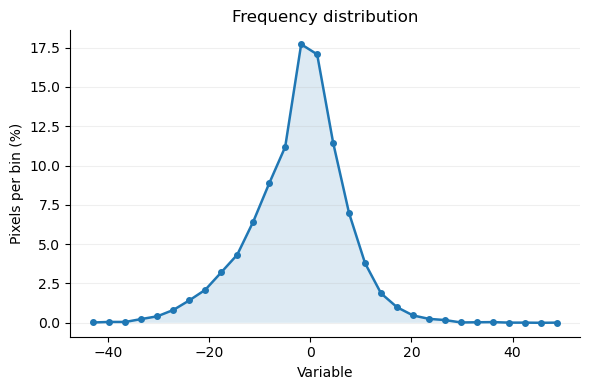

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Your data: works for NumPy arrays or xarray DataArrays
data = lahist['ef_2deg'].values.ravel()#*4.4**2
data = data[np.isfinite(data)]

# Define bins
nbins = 30
bin_edges = np.linspace(data.min(), data.max(), nbins + 1)

# Number of pixels in each bin
counts, bin_edges = np.histogram(data, bins=bin_edges)

# Values to plot
x = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # bin centres
y = counts / counts.sum() * 100              # percentage of pixels

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, y, marker="o", ms=4, lw=1.8)
ax.fill_between(x, 0, y, alpha=0.15)

ax.set(
    xlabel="Variable",
    ylabel="Pixels per bin (%)",
    title="Frequency distribution",
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

-3.442264530632082 0.7717369818329345 -4.861706891884534 -0.34857170773731233
ef_2deg 72.31028135527188 53.53679011246086 69.80790227719642 43.724297499156044
t2_2deg 301.4395825766948 303.7034914362291 306.7895387661176 309.5131656011114
div_2deg 0.3299991537147539 0.13564488934820973 0.021318746834453204 -0.5200755899318151
shear_2deg -16.380785772964373 -17.132901269316775 -17.284196195151747 -18.18544241160881
tcwv_2deg 45.41783399320913 44.27168990930727 67.29631361569172 65.72731684401057


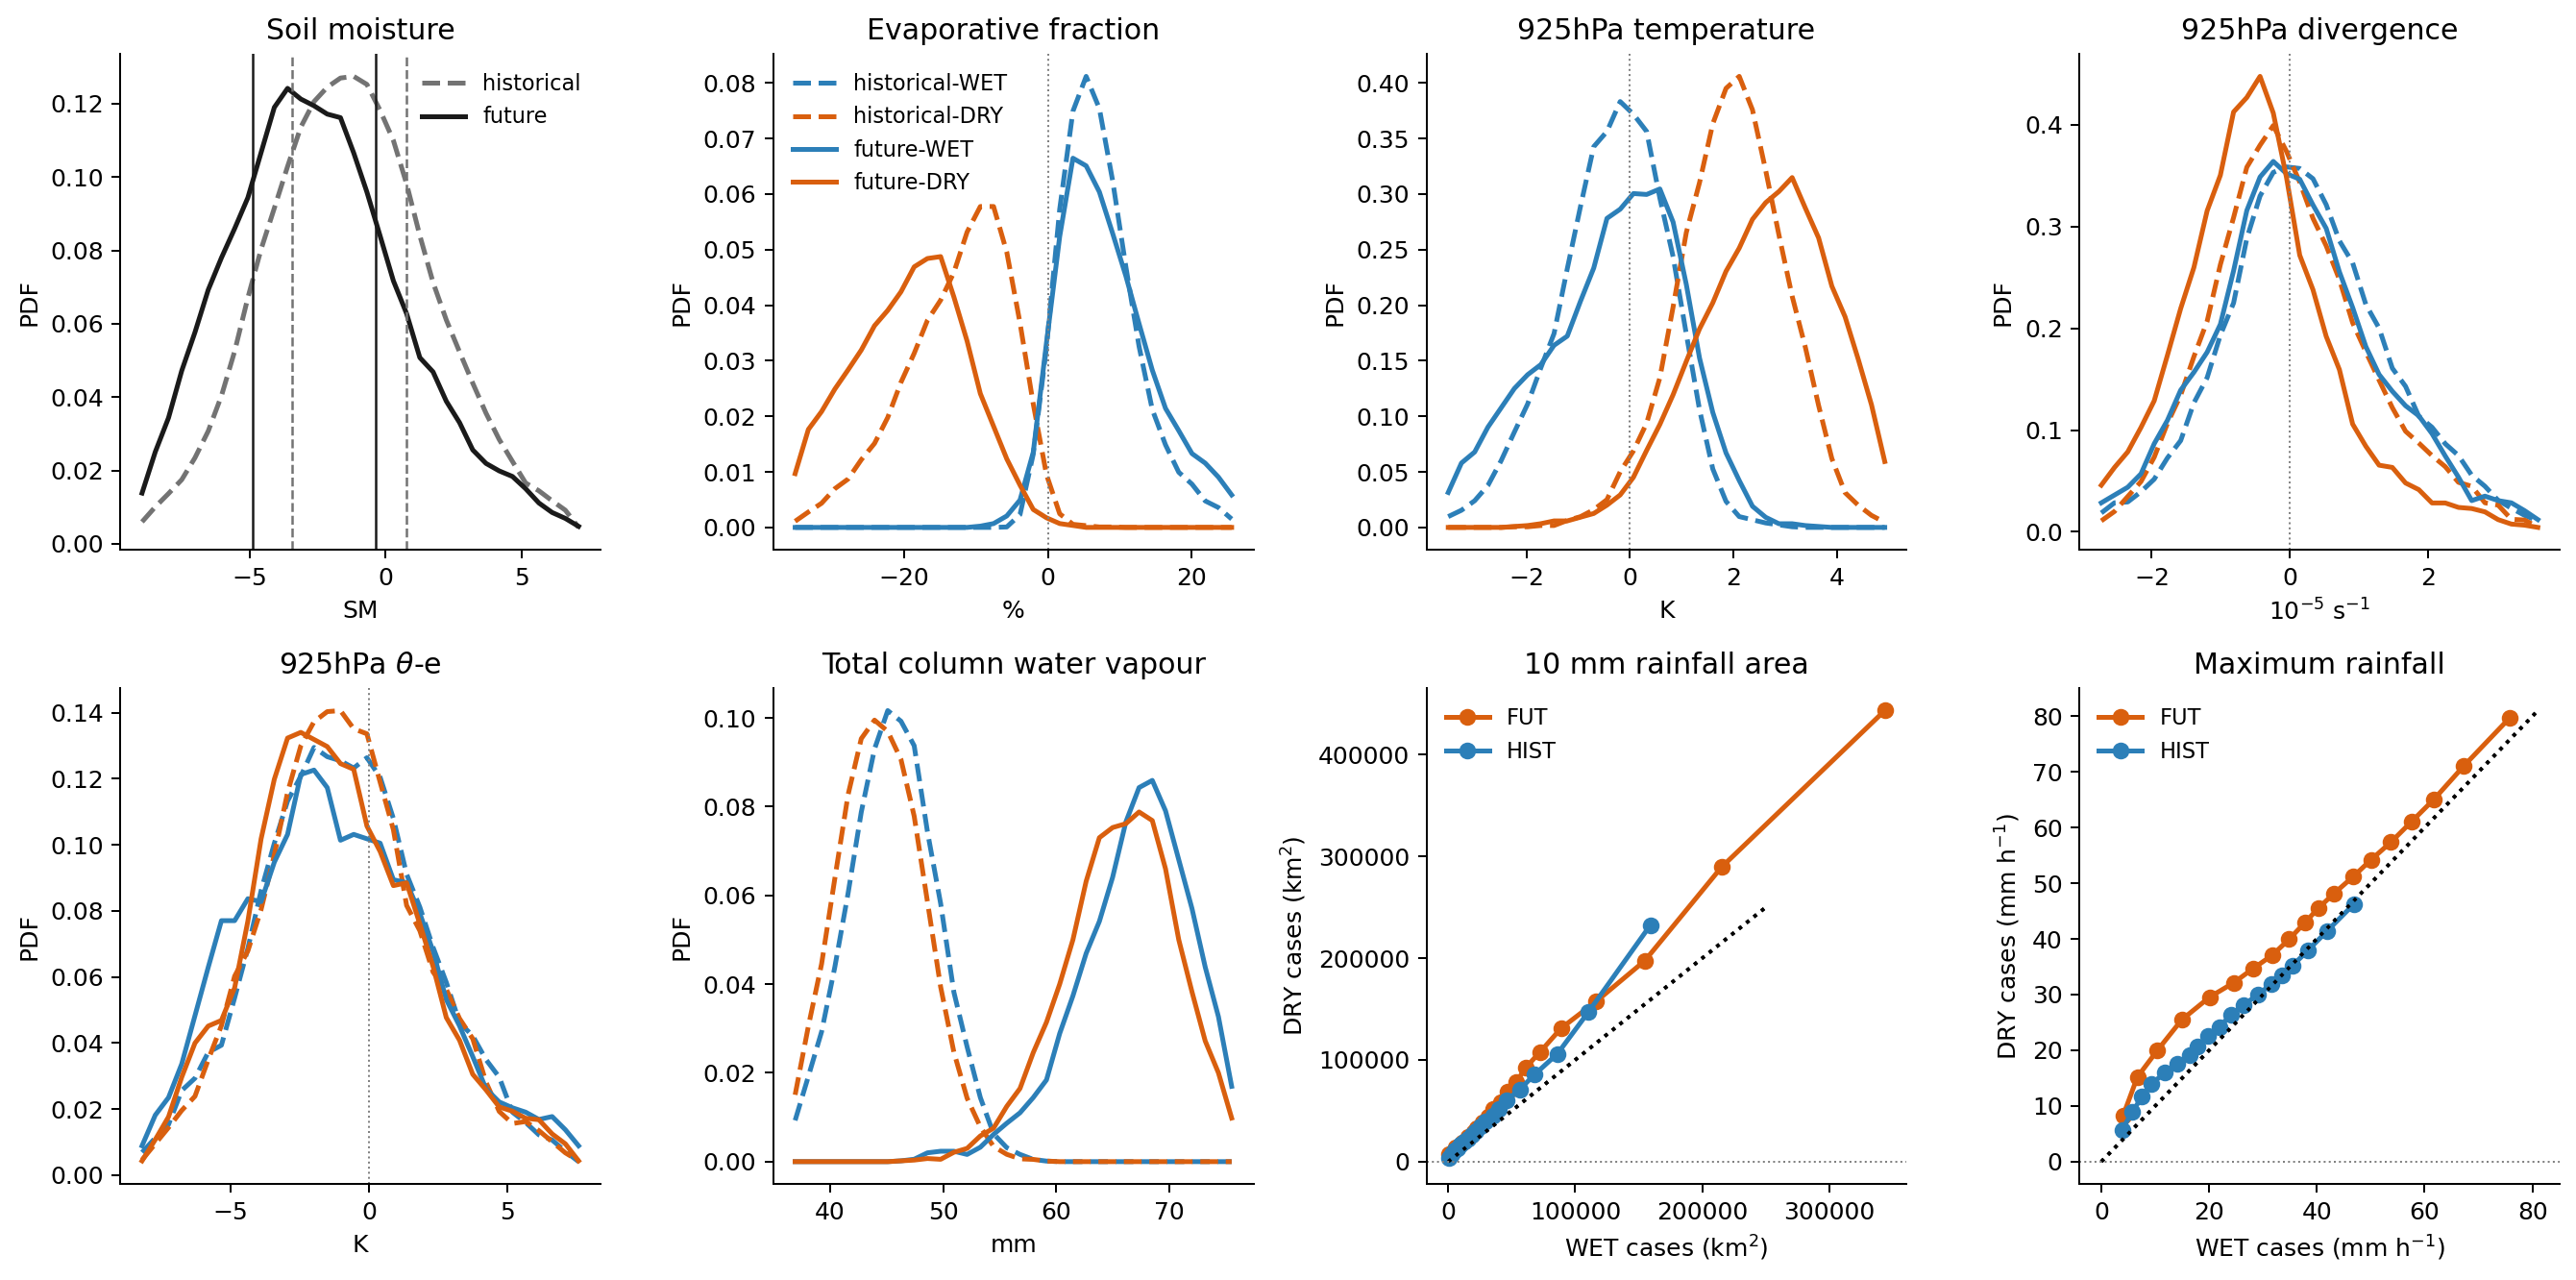

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SM split (same logic as your current code)
# ------------------------------------------------------------
histp25, histp75 = np.nanpercentile(lahist['SM_2deg'], [25, 75])
futp25, futp75   = np.nanpercentile(lafut['SM_2deg'], [25, 75])

histposlow  = lahist['SM_2deg'] > histp75   # WET
histposhigh = lahist['SM_2deg'] < histp25   # DRY
futposlow   = lafut['SM_2deg'] > futp75     # WET
futposhigh  = lafut['SM_2deg'] < futp25     # DRY

print(histp25, histp75, futp25, futp75)


# ------------------------------------------------------------
# Colours / styles
# ------------------------------------------------------------
wet_col  = '#2C7FB8'
dry_col  = '#D95F0E'
hist_col = '0.45'
fut_col  = '0.10'


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean(x, scale=1):
    x = np.asarray(x, dtype=float) * scale
    return x[np.isfinite(x)]

def _smooth(y, n=3):
    if n <= 1:
        return y
    kernel = np.ones(n) / n
    return np.convolve(y, kernel, mode='same')

def _make_bins(arrs, nbins=36, qrange=(1, 99)):
    zz = np.concatenate([a for a in arrs if len(a) > 0])
    lo, hi = np.nanpercentile(zz, qrange)
    return np.linspace(lo, hi, nbins + 1)

def _pdf(vals, bins, smooth=3):
    h, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5 * (edges[1:] + edges[:-1])
    return mids, _smooth(h, n=smooth)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

def plot_sm_pdf(ax):
    hsm = _clean(lahist['SM_2deg'])
    fsm = _clean(lafut['SM_2deg'])
    bins = _make_bins([hsm, fsm], nbins=34, qrange=(1, 99))

    x, y = _pdf(hsm, bins, smooth=3)
    ax.plot(x, y, color=hist_col, ls='--', lw=2, label='historical')

    x, y = _pdf(fsm, bins, smooth=3)
    ax.plot(x, y, color=fut_col, ls='-', lw=2, label='future')

    ax.axvline(histp25, color=hist_col, ls='--', lw=1)
    ax.axvline(histp75, color=hist_col, ls='--', lw=1)
    ax.axvline(futp25,  color=fut_col,  ls='-',  lw=1)
    ax.axvline(futp75,  color=fut_col,  ls='-',  lw=1)

    ymax = ax.get_ylim()[1]
    # ax.text(histp25, ymax*0.95, 'H25', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(histp75, ymax*0.95, 'H75', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(futp25,  ymax*0.85, 'F25', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)
    # ax.text(futp75,  ymax*0.85, 'F75', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)

    ax.set_title('Soil moisture')
    ax.set_xlabel('SM')
    ax.set_ylabel('PDF')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_group_pdf(ax, var, title, xlabel, scale=1, zero_line=False, nbins=34, qrange=(1, 99), smooth=3):

    if 'tcwv' not in var:
        hwet = _clean(lahist[var][histposlow], scale=scale)
        hdry = _clean(lahist[var][histposhigh], scale=scale)
        fwet = _clean(lafut[var][futposlow], scale=scale)
        fdry = _clean(lafut[var][futposhigh], scale=scale)
    else:
        hwet = _clean(lhist[var][histposlow], scale=scale)
        hdry = _clean(lhist[var][histposhigh], scale=scale)
        fwet = _clean(lfut[var][futposlow], scale=scale)
        fdry = _clean(lfut[var][futposhigh], scale=scale)

    hwet_mean = _clean(lhist[var][histposlow], scale=scale)
    hdry_mean = _clean(lhist[var][histposhigh], scale=scale)
    fwet_mean = _clean(lfut[var][futposlow], scale=scale)
    fdry_mean = _clean(lfut[var][futposhigh], scale=scale)

    print(var, np.mean(hwet_mean), np.mean(hdry_mean), np.mean(fwet_mean), np.mean(fdry_mean))

    bins = _make_bins([hwet, hdry, fwet, fdry], nbins=nbins, qrange=qrange)

    for vals, col, ls, lab in [
        (hwet, wet_col, '--', 'historical-WET'),
        (hdry, dry_col, '--', 'historical-DRY'),
        (fwet, wet_col, '-',  'future-WET'),
        (fdry, dry_col, '-',  'future-DRY')
    ]:
        x, y = _pdf(vals, bins, smooth=smooth)
        ax.plot(x, y, color=col, ls=ls, lw=2, label=lab)

    if zero_line:
        ax.axvline(0, color='0.5', ls=':', lw=0.8)
        
    if 'ef' in var:
        ax.legend(frameon=False, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    style_ax(ax)

def plot_area_panel(ax):
    # convert to km² if your area_10mm is in pixels
    pp = np.arange(5, 99, 5)

    # groups = [
    #     ('WET', _clean(lhist['area_1mm'][histposlow]),  _clean(lfut['area_1mm'][futposlow]),  wet_col),
    #    # ('ALL', _clean(lahist['area_10mm']),              _clean(lafut['area_10mm']),              '0.10'),
    #     ('DRY', _clean(lhist['area_1mm'][histposhigh]), _clean(lfut['area_1mm'][futposhigh]), dry_col)
    # ]
    groups = [
        ('FUT', _clean(lfut['area_5mm'][futposlow]),  _clean(lfut['area_5mm'][futposhigh]),  dry_col),
     #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
        ('HIST', _clean(lhist['area_5mm'][histposlow]), _clean(lhist['area_5mm'][histposhigh]), wet_col)
    ]

    for lab, histv, futv, col in groups:
        hq = np.nanpercentile((histv)*4.4**2, pp)
        fq = np.nanpercentile((futv)*4.4**2, pp)
        #ax.plot((hq)*4.4**2, (fq - hq)*4.4**2, color=col, lw=2, label=lab, marker='o')
        
        ax.plot((hq)*4.4**2, (fq)*4.4**2, color=col, lw=2, label=lab, marker='o')
        ax.plot(np.linspace(0,250000,10), np.linspace(0,250000,10), color='k', linestyle='dotted')
        
    ax.axhline(0, color='0.5', ls=':', lw=0.8)

    ax.set_title('10 mm rainfall area')
    ax.set_xlabel(r'WET cases (km$^{2}$)')
    ax.set_ylabel('DRY cases (km$^{2}$)')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_pmax_panel(ax):
    pp = np.arange(5, 99, 5)

    # groups = [
    #     ('WET', _clean(lhist['pmax'][histposlow]),  _clean(lfut['pmax'][futposlow]),  wet_col),
    #  #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
    #     ('DRY', _clean(lhist['pmax'][histposhigh]), _clean(lfut['pmax'][futposhigh]), dry_col)
    # ]

    groups = [
        ('FUT', _clean(lfut['pmax'][futposlow]),  _clean(lfut['pmax'][futposhigh]),  dry_col),
     #   ('ALL', _clean(lahist['pmax']),              _clean(lafut['pmax']),              '0.10'),
        ('HIST', _clean(lhist['pmax'][histposlow]), _clean(lhist['pmax'][histposhigh]), wet_col)
    ]


    for lab, histv, futv, col in groups:
        hq = np.nanpercentile(histv, pp)
        fq = np.nanpercentile(futv, pp)
        #ax.plot(hq, (fq - hq), color=col, lw=2, label=lab, marker='o')
        ax.plot(hq, fq, color=col, lw=2, label=lab, marker='o')
        ax.plot(np.linspace(0,81,10), np.linspace(0,81,10), color='k', linestyle='dotted')

    ax.axhline(0, color='0.5', ls=':', lw=0.8)
    ax.set_title('Maximum rainfall')
    ax.set_xlabel(r'WET cases (mm h$^{-1}$)')
    ax.set_ylabel('DRY cases (mm h$^{-1}$)')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(2,4, figsize=(15, 7.5), dpi=180)
axs = axs.ravel()

# 1) full SM distribution
plot_sm_pdf(axs[0])

# 2-6) associated environmental variables
plot_group_pdf(axs[1], 'ef_2deg',   'Evaporative fraction',         '%', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[2], 't2_2deg',   '925hPa temperature',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[3], 'div_2deg',  '925hPa divergence',     '$10^{-5}$ s$^{-1}$', scale=1e5, zero_line=True, nbins=34, qrange=(1, 99)),
plot_group_pdf(axs[4], 'shear_2deg',   r'925hPa $\theta$-e',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[5], 'tcwv_2deg',   'Total column water vapour','mm',         zero_line=False, nbins=34, qrange=(1, 99))

               

# 7-8) storm characteristics
plot_area_panel(axs[6])
plot_pmax_panel(axs[7])

plt.tight_layout()
# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SMsplit_variable_distributions_clean.png', dpi=200)
plt.show()

In [46]:
import scipy.stats as stats
from scipy.stats import gaussian_kde, linregress
def calc_density(v1,v2):

    xy = np.vstack([v1, v2])

    z = gaussian_kde(xy)(xy)

    return z / (z.max() - z.min())

# cp4s = [lhist[var2], lhist[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='viridis')

# cp4s = [lfut[var2], lfut[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='inferno', alpha=0.3)

In [47]:
from scipy.stats import binned_statistic
def binning(dic, var1, var2, bins):
    func = lambda y: np.nanmean(y)   #  could also be np.percentile(y, 95) etc.
    #func = lambda y: np.nanpercentile(y, 95)  #  could also be np.percentile(y, 95) etc.
    dat, bin_edges, binnumber = binned_statistic(dic[var1], dic[var2], statistic=func, bins=bins)
    tcbins = bin_edges[0:-1] + (bin_edges[1::]-bin_edges[0:-1])/2
  #  ipdb.set_trace()
    pslope, pintercept, pr_value, pp_value, pstd_err = stats.linregress(tcbins[np.isfinite(dat)], dat[np.isfinite(dat)])

    return dat, tcbins, pslope, pintercept, pp_value

SM_1deg dclim: -2.6784918207110895 danom: -1.3809964526290803 dstorm: -4.05948827334017
sh_1deg dclim: 18.10740061530049 danom: 18.11775337693595 dstorm: 36.22515399223644
lh_1deg dclim: -24.854025706645274 danom: -30.375825298029675 dstorm: -55.22985100467494
sw_net_1deg dclim: -17.32961187411115 danom: -9.370392278966236 dstorm: -26.700004153077316
t_srfc_1deg dclim: 5.707954362757619 danom: 0.3445471907623577 dstorm: 6.05250155351996
q_srfc_1deg dclim: 0.004653099086321664 danom: 0.00018192563788313161 dstorm: 0.004835024724204795
tcwv_1deg dclim: 19.277592499791595 danom: 1.7298543662883548 dstorm: 21.007446866079952
thetae_srfc_1deg dclim: 6.093127860803406 danom: 0.13883772110159498 dstorm: 6.231965581905001
div_1deg dclim: -1.31814749853006e-06 danom: -3.539532179100361e-06 dstorm: -4.85767967763042e-06
geoH_srfc_1deg dclim: 12.74848009327502 danom: -0.6886856687452941 dstorm: 12.059794424529741
shear_1deg dclim: -0.7713769618014439 danom: -0.09802296507031483 dstorm: -0.8693999

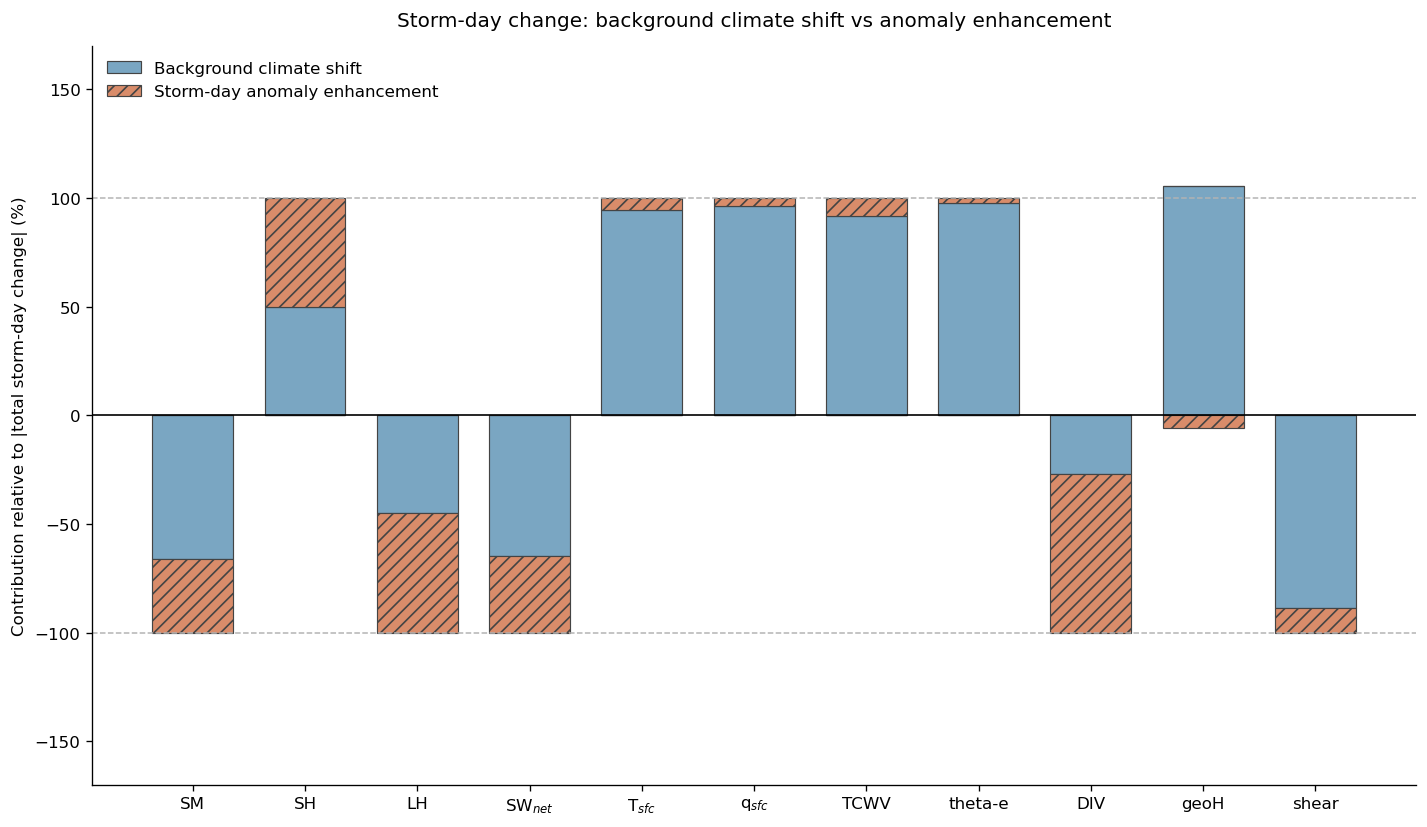

In [48]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

clim = []
anom = []

varts = ['SM_1deg',
         'sh_1deg', 'lh_1deg', 'sw_net_1deg',
         't_srfc_1deg',
         'q_srfc_1deg', 'tcwv_1deg',
         'thetae_srfc_1deg', 'div_1deg', 'geoH_srfc_1deg', 'shear_1deg']

lab = {'q_srfc_1deg': 'q$_{sfc}$',
       'tcwv_1deg': 'TCWV',
       't_srfc_1deg': 'T$_{sfc}$',
       'lh_1deg': 'LH',
       'sh_1deg': 'SH',
       'thetae_srfc_1deg': 'theta-e',
       'div_1deg': 'DIV',
       'sw_net_1deg': 'SW$_{net}$',
       'SM_1deg': 'SM',
       'geoH_srfc_1deg' : 'geoH',
       'shear_1deg' : 'shear'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm)

    if np.isclose(dstorm, 0):
        clim.append(np.nan)
        anom.append(np.nan)
    else:
        clim.append(dclim / np.abs(dstorm) * 100.)
        anom.append(danom / np.abs(dstorm) * 100.)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)

# Positive and negative parts for signed stacking
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)
anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

# Colours
c_clim = '#7AA6C2'   # muted blue
c_anom = '#D98C6A'   # muted terracotta
edge   = '#444444'

ax.bar(x, clim_pos, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.72, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.72, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)
ax.axhline(100, color='0.7', lw=0.9, ls='--')
ax.axhline(-100, color='0.7', lw=0.9, ls='--')

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Contribution relative to |total storm-day change| (%)')
ax.set_title('Storm-day change: background climate shift vs anomaly enhancement', pad=12)

ax.set_ylim(-170, 170)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

SM_2deg dclim: -2.6760394363395914 danom: -1.1782220888083081 dstorm: -3.8542615251478995
sh_2deg dclim: 18.69303930169403 danom: 14.096458008185063 dstorm: 32.789497309879096
lh_2deg dclim: -24.707683263217262 danom: -24.182520581522606 dstorm: -48.89020384473989
ef_2deg dclim: -5.843707478131215 danom: -4.280999058188612 dstorm: -10.124706536319827
sw_net_2deg dclim: -16.422948906335137 danom: -8.60508197378767 dstorm: -25.028030880122742
t_srfc_2deg dclim: 5.749911677452133 danom: 0.27781395442032464 dstorm: 6.027725631872443
q_srfc_2deg dclim: 0.004645664402514647 danom: 0.0002399011783877175 dstorm: 0.004885565580902366
tcwv_2deg dclim: 19.205612167278986 danom: 1.7087706070333377 dstorm: 20.914382774312323
vpd_srfc_2deg dclim: 6.215596799643334 danom: 0.5464709248116565 dstorm: 6.762067724454992
cape_proxy_2deg dclim: nan danom: 0.3396118571730611 dstorm: nan
div_2deg dclim: -1.5795621897248407e-06 danom: -3.013853811847717e-06 dstorm: -4.593416001572558e-06


/tmp/ipykernel_785/308101744.py:26: RuntimeWarning: Mean of empty slice
  stormhist = np.nanmean(lhist[v].dropna())
/tmp/ipykernel_785/308101744.py:27: RuntimeWarning: Mean of empty slice
  stormfut  = np.nanmean(lfut[v].dropna())


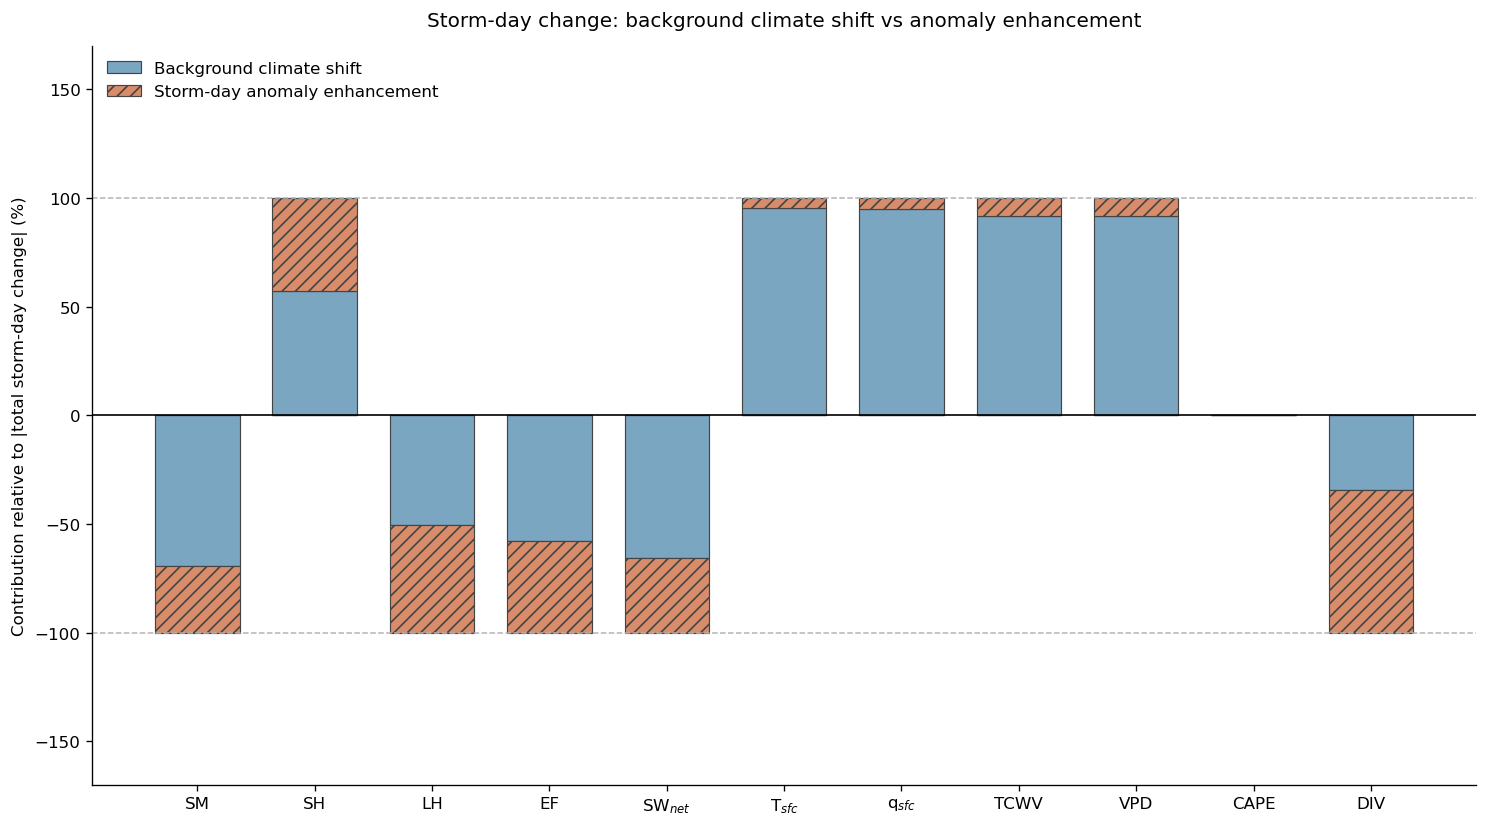

In [36]:
fig, ax = plt.subplots(figsize=(12.5, 7), dpi=120)

clim = []
anom = []

varts = ['SM_2deg',
         'sh_2deg', 'lh_2deg', 'ef_2deg', 'sw_net_2deg',
         't_srfc_2deg',
         'q_srfc_2deg', 'tcwv_2deg', 'vpd_srfc_2deg',
         'cape_proxy_2deg', 'div_2deg']

lab = {'SM_2deg': 'SM',
       'sh_2deg': 'SH',
       'lh_2deg': 'LH',
       'ef_2deg': 'EF',
       'sw_net_2deg': 'SW$_{net}$',
       't_srfc_2deg': 'T$_{sfc}$',
       'q_srfc_2deg': 'q$_{sfc}$',
       'tcwv_2deg': 'TCWV',
       'vpd_srfc_2deg': 'VPD',
       'cape_proxy_2deg': 'CAPE',
       'div_2deg': 'DIV'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm)

    if np.isclose(dstorm, 0):
        clim.append(np.nan)
        anom.append(np.nan)
    else:
        clim.append(dclim / np.abs(dstorm) * 100.)
        anom.append(danom / np.abs(dstorm) * 100.)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)

# positive and negative pieces for correct signed stacking
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)

anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

c_clim = '#7AA6C2'
c_anom = '#D98C6A'
edge = '#444444'

ax.bar(x, clim_pos, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.72, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.72, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)
ax.axhline(100, color='0.7', lw=0.9, ls='--')
ax.axhline(-100, color='0.7', lw=0.9, ls='--')

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Contribution relative to |total storm-day change| (%)')
ax.set_title('Storm-day change: background climate shift vs anomaly enhancement', pad=12)

ax.set_ylim(-170, 170)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

sh_2deg dclim: 18.69303930169403 danom: 14.096458008185063 dstorm: 32.789497309879096 stormhist: 157.6023145473142 stormfut: 190.3918118571933 anohist: 14.668277751248262 anofut: 28.764735759433325
lh_2deg dclim: -24.707683263217262 danom: -24.182520581522606 dstorm: -48.89020384473989 stormhist: 261.37334479509303 stormfut: 212.48314095035315 anohist: 13.368836891235064 anofut: -10.813683690287542
sw_net_2deg dclim: -16.422948906335137 danom: -8.60508197378767 dstorm: -25.028030880122742 stormhist: 604.4326533668047 stormfut: 579.404622486682 anohist: 38.7118547394162 anofut: 30.106772765628527


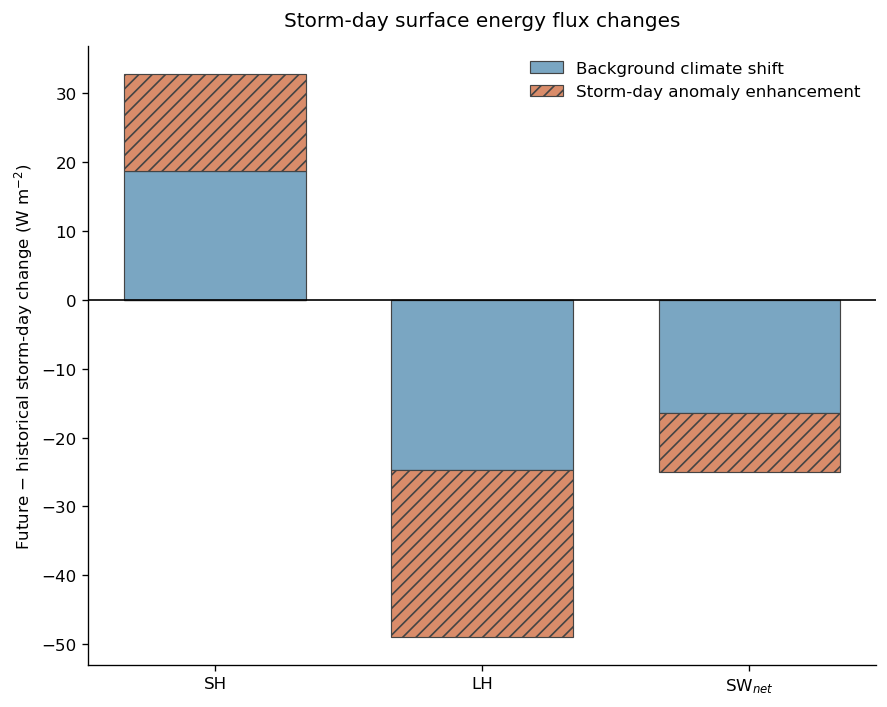

In [37]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 6), dpi=120)

clim = []
anom = []
storm = []

varts = ['sh_2deg', 'lh_2deg', 'sw_net_2deg']

lab = {'sh_2deg': 'SH',
       'lh_2deg': 'LH',
       'sw_net_2deg': 'SW$_{net}$'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm,
          'stormhist:', stormhist, 'stormfut:', stormfut,
          'anohist:', anohist, 'anofut:', anofut)

    clim.append(dclim)
    anom.append(danom)
    storm.append(dstorm)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)
storm = np.array(storm)

# split positive / negative contributions for correct stacking around zero
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)

anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

c_clim = '#7AA6C2'   # muted blue
c_anom = '#D98C6A'   # muted terracotta
edge   = '#444444'

ax.bar(x, clim_pos, width=0.68, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.68, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.68, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.68, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Future − historical storm-day change (W m$^{-2}$)')
ax.set_title('Storm-day surface energy flux changes', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='best')

plt.tight_layout()
plt.show()